### Required Assignment 6.1: Analyzing results of PCA, Plotting values and Adjusting Parameters for Variance

**Expected Time: 120 Minutes**

**Total Points: 28**

This activity explores principal component analysis through two examples -- image data and tabular data. These examples are meant to demonstrate how PCA extracts important information from the data while reducing its dimensionality. Next, you will build a scree plot with Python. A scree plot can be used to determine how many Principal Components to keep in a given dataset.  Using a `sklearn` built-in housing dataset, you will plot the values of $\Sigma$ in decreasing order -- this is a scree plot.  For more on scree plots see [here](https://en.wikipedia.org/wiki/Scree_plot#:~:text=In%20multivariate%20statistics%2C%20a%20scree,principal%20component%20analysis%20(PCA).). In the last part of this activity, you will determine how many components are required to explain a proportion of variance.  
### Index:

- [Problem 1](#Problem-1)
- [Problem 2](#Problem-2)
- [Problem 3](#Problem-3)
- [Problem 4](#Problem-4)
- [Problem 5](#Problem-5)
- [Problem 6](#Problem-6)
- [Problem 7](#Problem-7)
- [Problem 8](#Problem-8)
- [Problem 9](#Problem-9)
- [Problem 10](#Problem-10)

In [2]:
from scipy.linalg import svd
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_olivetti_faces, fetch_california_housing
from sklearn.datasets import make_regression
from sklearn.datasets import fetch_openml

#### The Datasets

Both datasets are built into the `sklearn` library.  The first is a familiar set of faces, such as 1-Dimensional Arrays, and the second is a dataset on housing prices in Californian neighborhoods.  The image data is limited to a single image and assigned to the variable `image` below.  The housing data is displayed as a DataFrame with the `.frame` attribute after setting `as_frame = True`.  

In [3]:
faces_data = pd.read_csv('data/faces.csv')
cali_housing = fetch_california_housing(return_X_y=False, as_frame=True, data_home='data')

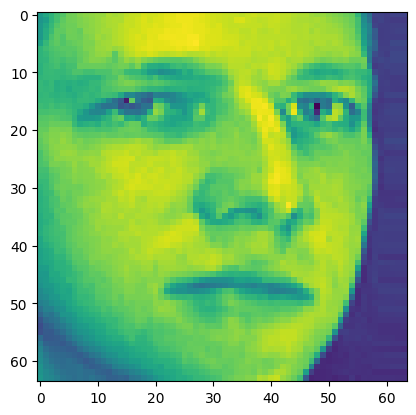

In [4]:
image = faces_data.iloc[4].values.reshape(64, 64)
plt.imshow(image)

In [5]:
df = cali_housing.frame.head(5)
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


### Principal Component Analysis 

Recall the steps to perform Principal Component Analysis on an array.  

```
- standardize the data
- perform SVD
- select how many components to keep
```

From here, depending on the goal, you will either eliminate all but the top `r` values in $\Sigma$ or evaluate the product of $U_r \dot \Sigma_r$.

[Back to top](#Index:) 

## Problem 1

### Function to Standardize and Factor

**4 Points**

Complete the function `svd_norm` according to the instructions below:

- The function should take, as input, an array `X`.
- The function should scale the array `X` using its mean and standard deviation and assign the result to ` x_norm`.
- The function should use the `svd` function to factor `x_norm` using `full_matrices` equal to `False` and assign the result to `U`, `sigma`, and `VT`.
- The function should use `np.diag()` to define a diagonal matrix with the singular values on the main diagonal and assign the result to `Sigma`.
- The function should return three arrays `U`, `Sigma` and `VT`.


In [10]:
### GRADED

def svd_norm(X):
    """This function takes in an array X, scales it according 
    to the transformation X - mu / sigma where mu is the mean
    and sigma the standard deviation of the dataset.

    Parameters
    ----------
    X: type `np.array`, shape (N, M)
        
    Returns
    -------
    A tuple (U, Sigma, VT) where
        U: type `np.ndarray`, shape (N, M)
            Numpy arrays with N rows, M columns 
        Sigma: type `np.ndarray`, shape (M, M)
            Numpy arrays with M rows and M columns
            A Diagonal matrix with the singular values on main diagonal
        VT: type `np.ndarray`, shape (M, M)
            Numpy array with M rows and M columns representing V Transpose
    """
    return None


def svd_norm(X):
    x_norm = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
    U, s, VT = svd(x_norm, full_matrices=False)
    Sigma = np.diag(s)
    return U, Sigma, VT

### BEGIN SOLUTION
#def svd_norm(X):
  #  x_norm =( X - X.mean())/X.std()
 #   U, sigma, VT = svd(x_norm, full_matrices=False)
 #   Sigma = np.diag(sigma)
 #   return U, Sigma, VT
### END SOLUTION

# Answer check
x_norm = (image - np.mean(image, axis=0)) / np.std(image, axis=0)

U, Sigma, VT = svd_norm(image)
print(U.shape, Sigma.shape, VT.shape)
print(np.allclose(x_norm, U @ Sigma @ VT))

(64, 64) (64, 64) (64, 64)
True


In [7]:
np.allclose(x_norm, U @ Sigma @ VT)

NameError: name 'x_norm' is not defined

[Back to top](#Index:) 

## Problem 2

### Reconstructing the Image

**4 Points**

To complete this problem, follow the instructions below:

- Apply the `svd_norm` function you defined in Problem 1 to `image` and assign the result to `U`, `Sigma`, and `VT`.
- Use the `np.copy` function with argument `Sigma` to make a copy of the $\Sigma$ matrix and assign  the result to `Sigma_copy`.
- Set all but the first 5 singular values of `Sigma_copy` (first 25 values - 5x5 matrix) to zero.
-  Reconstruct the original image by multiplying $U \Sigma_{copy} VT$ with the `@` operator and assign the result to `simpler_image`. 

Note how much information from the image is captured in the first five singular values!

(64, 64)


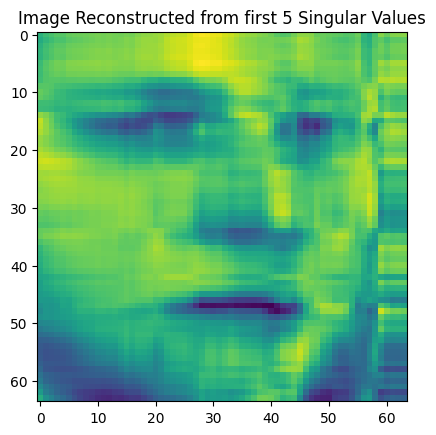

In [11]:
### GRADED

Sigma_copy = None
simpler_image = None

### BEGIN SOLUTION
U, Sigma, VT = svd_norm(image)
Sigma_copy = np.copy(Sigma)
Sigma_copy[5:, 5:] = 0
simpler_image = U@Sigma_copy@VT
### END SOLUTION

# Answer check
print(simpler_image.shape)
plt.imshow(simpler_image)
plt.title('Image Reconstructed from first 5 Singular Values');

[Back to top](#Index:) 

## Problem 3

### Repeat for Tabular Data

**4 Points**

As the example above demonstrates, using Principal Component Analysis is a way of extracting important information from the data through the SVD.  Now, you are to extract the matrix factorization from the SVD using the housing data `df`.  The earlier `svd_norm` function should work to factor a DataFrame.  Use your function to extract $U, \Sigma, VT$ from the DataFrame.  Assign your results to `U, Sigma, VT` below.

In [12]:
### GRADED

U, Sigma, VT = None, None, None

### BEGIN SOLUTION
U, Sigma, VT = svd_norm(df)
### END SOLUTION

# Answer check
print(type(U))
print(df.shape, Sigma.shape)

<class 'numpy.ndarray'>
(5, 9) (5, 5)


[Back to top](#Index:) 

## Problem 4

## Function to project into lower dimension `r`

**4 Points**

Complete the function `pca` below according to the instructions below:

- The function takes two arguments, `X` and `r` where `X` is an array or DataFrame and `r` is a dimension to project the data down into.
- The function should scale the array `X` using its mean and standard deviation and assign the result to ` x_norm`.
- The function should use the `svd` function to factor `x_norm` using `full_matrices` equal to `False` and assign the result to `U`, `sigma`, and `VT`.
- The function should use `np.diag()` to define a diagonal matrix with the singular values on the main diagonal and assign the result to `Sigma`.
- The function should extract all the rows and the first `r` columns of `U` and assign the result to `Ur`.
- The function should extract the first `r` rows and columns of `Sigma` and assign the result to `Sigma_r`.
- The function should returns a DataFrame of shape `(N, r)` with columns labeled `pca_1`, `pca_2`, ..., `pca_r`. To achieve this use the code `pd.DataFrame(Ur @ Sigma_r, columns = [f'pca_{i}' for i in range(1, r + 1)])`



In [13]:
### GRADED

def pca(X, r = 5):
    """This function takes in an array X, and extracts
    r principal components.  These are returned in a DataFrame.

    Parameters
    ----------
    X: type `np.array`, shape (N, M)
    r: type `int`
        
    Returns
    -------
    A DataFrame of shape (N, r) with columns labeled
    pca_1. | pca_2 | .... | pca_r |
    
    """
    return None

### BEGIN SOLUTION
def pca(X, r = 5):
    x_norm =( X - X.mean())/X.std()
    U, sigma, VT = svd(x_norm, full_matrices=False)
    Sigma = np.diag(sigma)
    Ur = U[:, :r]
    Sigma_r = Sigma[:r, :r]
    return pd.DataFrame(Ur @ Sigma_r, columns = [f'pca_{i}' for i in range(1, r + 1)])

### END SOLUTION

# Answer check
XT = pca(df, r = 2)
print(XT.shape)
XT.head()

(5, 2)


,pca_1,pca_2
0,-1.473319,2.134378
1,-3.153742,-1.549201
2,1.205018,1.330209
3,1.610373,-0.625768
4,1.811671,-1.289619


These examples offer insight into how PCA can reduce the dimensionality of your data while keeping important information about underlying relationships intact.  

[Back to top](#Index:) 

## Problem 5

### Extracting $\Sigma$

**2 Points**

Complete the function `singular_values` according to the instructions below:

- The function takes, as input, an aray `X`, and a booloean flag `scale`, describing whether you want to scale the array `X` or not.
- Using an `if` statement, check if `scale` is `True`. If it is, scale `X` using its mean and standard deviation.
- If `scale` is not `True`, use the `svd` function to factor `X` into  `u`, `sigma`, and `vt`.
- The function should return the numpy array of singular values of X, `sigma`.

In [14]:
### GRADED

def singular_values(X, scale = False):
    """Return the singular values resulting from 
    SVD decomposition.  

    Parameters
    ----------
    X: np.array or pd.DataFrame
        An array of data
    scale: boolean
        Boolean determines whether data needs to be scaled

    Returns an numpy array of singular values of X
    """
    # YOUR CODE HERE 
    return None # replace with your return statement

### BEGIN SOLUTION
def singular_values(X, scale = False):
    if scale:
        X = (X - X.mean())/X.std()
        
    u, sigma, vt = svd(X)
    return sigma
### END SOLUTION

# Answer check
print(type(singular_values(df)))
sigma = singular_values(df)
print(sigma.shape)

<class 'numpy.ndarray'>
(5,)


In [15]:
sigma = singular_values(df)

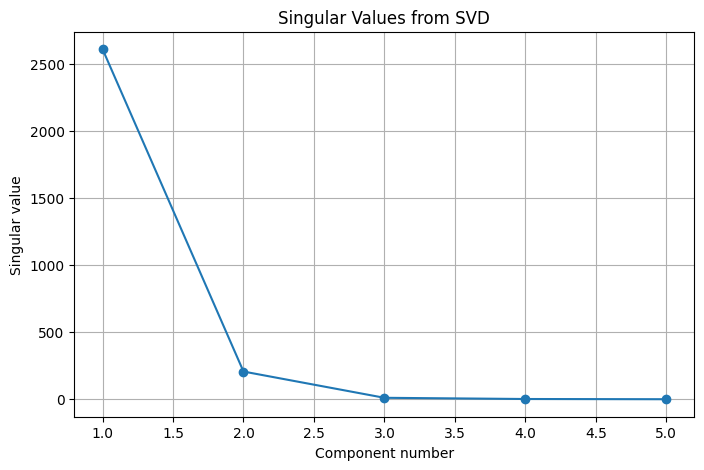

In [16]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(8,5))
plt.plot(np.arange(1, len(sigma)+1), sigma, marker='o')
plt.title('Singular Values from SVD')
plt.xlabel('Component number')
plt.ylabel('Singular value')
plt.grid(True)
plt.show()

[Back to top](#Index:) 

## Problem 6

### Plotting $\Sigma$

**1 Points**

Using the function above, build a plot of the singular values. Use your plot to determine how many principal components you should keep from the dataframe `df`.  Assign your solution as an integer to `ans2` below.

In [ ]:
### GRADED

#plot of singular values here

#how many components should you keep?
ans2 = ''

### BEGIN SOLUTION
ans2 = 2
### END SOLUTION

Depending on the dataset, we may have a different number of principal components to keep.  While not a hard fast statistical test, using a scree plot can provide some information on the appropriate number of values to keep.  

In the last part of the assignment, you will use a dataset that is a larger example of a housing dataset related to individual houses and features in Ames Iowa.  For our purposes the non-null numeric data is selected. To import the data, run the code cells below:

In [17]:
#fetching the data
housing = fetch_openml(name="house_prices", as_frame=True, data_home='data')

In [18]:
#examine the dataframe
housing.frame

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,1456,60,RL,62.0,7917,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,8,2007,WD,Normal,175000
1456,1457,20,RL,85.0,13175,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,2,2010,WD,Normal,210000
1457,1458,70,RL,66.0,9042,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,GdPrv,Shed,2500,5,2010,WD,Normal,266500
1458,1459,20,RL,68.0,9717,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,142125


In [19]:
#select numeric data and drop missing values
df = housing.frame.select_dtypes(['float', 'int']).dropna(axis = 1)#.select_dtypes(['int', 'float'])

[Back to top](#Index:) 

## Problem 7

### Scale the data

**2 Points**

Scale the `df` data using its mean and standard deviation so that it is ready for SVD.  Assign the scaled data to `df_scaled` below.  

In [20]:
### GRADED

df_scaled = ''

### BEGIN SOLUTION
df_scaled = (df - df.mean())/df.std()
### END SOLUTION

# Answer check
print(type(df_scaled))

<class 'pandas.core.frame.DataFrame'>


[Back to top](#Index:) 

## Problem 8

### Extracting $\Sigma$

**2 Points**

Using the scaled data, extract the singular values from the data using the `scipy.linalg` function `svd`.  Assign your results to `U`, `sigma`, and `VT` below. 

In [21]:
### GRADED

U, sigma, VT = '', '', ''

### BEGIN SOLUTION
U, sigma, VT = svd(df_scaled)
### END SOLUTION

# Answer check
print(type(sigma))
print(sigma.shape)

<class 'numpy.ndarray'>
(35,)


[Back to top](#Index:) 

## Problem 9

### Percent Variance Explained

**2 Points**

Divide `sigma` by the sum of the singular values to compute the percent variance explained. Assign your result as a percent array to `percent_variance_explained` below.  

Note that due to rounding this percent won't sum to exactly 1.  

In [22]:
### GRADED

percent_variance_explained = ''

### BEGIN SOLUTION
U, sigma, VT = svd(df_scaled)
percent_variance_explained = sigma/sigma.sum()
### END SOLUTION
print(percent_variance_explained.shape)
print(percent_variance_explained.sum())

(35,)
1.0


[Back to top](#Index:) 

## Problem 10

### Cumulative Variance Explained

**3 Points**

Using the solution to problem 10, how many principal components are necessary to retain up to 80% of the explained variance if we consider them in descending order?  Assign your response to `ans11` below as an integer. 

**HINT**: explore the `np.cumsum` function.

In [23]:
### GRADED

ans10 = ''

### BEGIN SOLUTION
U, sigma, VT = svd(df_scaled)
percent_variance_explained = sigma/sigma.sum()
ans10 = int((np.cumsum(percent_variance_explained) < .8).sum())


### END SOLUTION
print(type(ans10))
print(ans10)

<class 'int'>
21


In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

# reproducibility
np.random.seed(42)

# pretend we have 25 kinematic variables
columns = [f"feature_{i+1}" for i in range(25)]

# make a correlated dataset (some shared motion patterns)
base = np.random.randn(10000, 3)
A = (base @ np.random.randn(3, 25)) + 0.2*np.random.randn(10000, 25)
df = pd.DataFrame(A, columns=columns)

# standardize (very important before SVD)
A_scaled = StandardScaler().fit_transform(df)

In [25]:
U, sigma, Vt = np.linalg.svd(A_scaled, full_matrices=False)
V = Vt.T   # easier to read (columns = components)

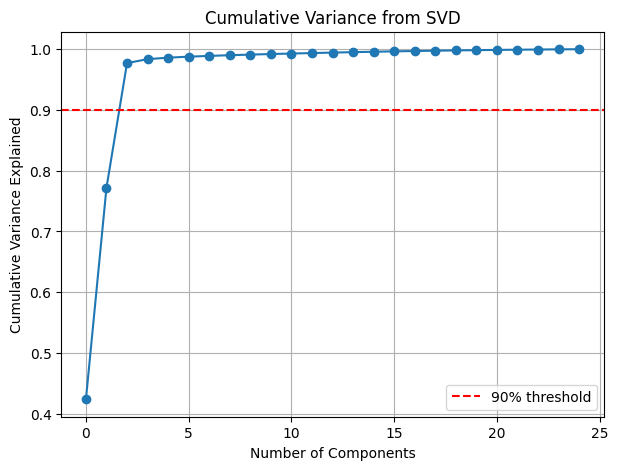

Keep the first 3 components for 90% variance


In [26]:
var_explained = (sigma**2) / np.sum(sigma**2)
cum_var = np.cumsum(var_explained)

plt.figure(figsize=(7,5))
plt.plot(cum_var, marker='o')
plt.axhline(0.9, color='r', linestyle='--', label='90% threshold')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance Explained")
plt.title("Cumulative Variance from SVD")
plt.legend()
plt.grid(True)
plt.show()

# how many components reach 90%
k = np.argmax(cum_var >= 0.9) + 1
print(f"Keep the first {k} components for 90% variance")

In [27]:
for i in range(k):
    loadings = pd.Series(V[:, i], index=df.columns)
    top_features = loadings.abs().sort_values(ascending=False).head(5)
    print(f"\nTop features influencing Component {i+1}:")
    print(top_features)


Top features influencing Component 1:
feature_12    0.296047
feature_20    0.288342
feature_21    0.282781
feature_17    0.279579
feature_11    0.274941
dtype: float64

Top features influencing Component 2:
feature_18    0.333686
feature_2     0.330431
feature_5     0.326703
feature_13    0.321643
feature_7     0.312451
dtype: float64

Top features influencing Component 3:
feature_19    0.371913
feature_16    0.356669
feature_25    0.350024
feature_9     0.322884
feature_4     0.312396
dtype: float64


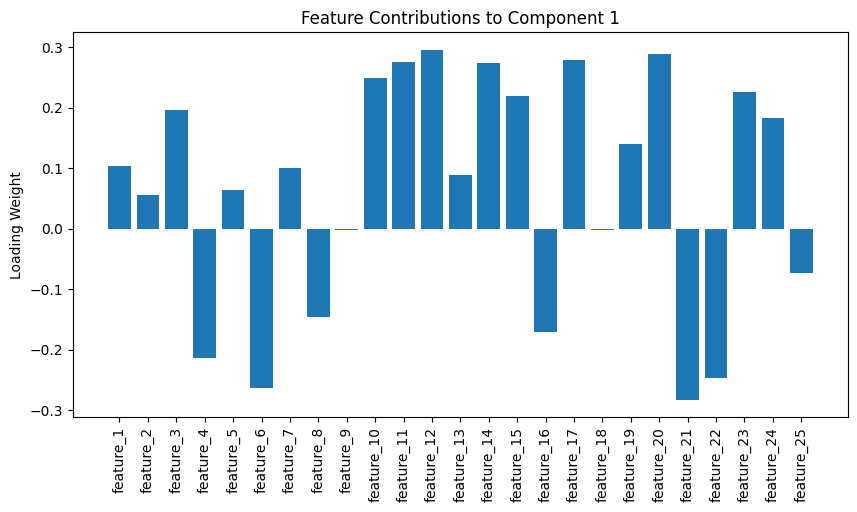

In [28]:
comp = 0  # first principal component
plt.figure(figsize=(10,5))
plt.bar(df.columns, V[:,comp])
plt.xticks(rotation=90)
plt.title(f"Feature Contributions to Component {comp+1}")
plt.ylabel("Loading Weight")
plt.show()

In [29]:
# compute global influence per feature
feature_influence = np.sum((sigma[:k]**2) * (V[:, :k]**2), axis=1)
pd.Series(feature_influence, index=df.columns).sort_values(ascending=False)

feature_15    9942.677448
feature_3     9925.191660
feature_19    9912.607722
feature_1     9911.910345
feature_5     9906.791643
feature_12    9905.922180
feature_4     9897.479792
feature_8     9891.235897
feature_10    9870.685078
feature_17    9866.969620
feature_24    9857.362246
feature_13    9846.379663
feature_2     9842.730013
feature_21    9827.585811
feature_7     9819.314438
feature_20    9813.224859
feature_25    9809.146118
feature_6     9796.837583
feature_23    9785.393343
feature_22    9783.216107
feature_9     9742.560537
feature_18    9725.829624
feature_16    9655.451535
feature_14    9439.085991
feature_11    8509.588211
dtype: float64

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

np.random.seed(0)

# create synthetic correlated dataset
columns = [f"feature_{i+1}" for i in range(10)]
base = np.random.randn(5000, 3)
A = (base @ np.random.randn(3, 10)) + 0.2*np.random.randn(5000, 10)
df = pd.DataFrame(A, columns=columns)

# standardize
A_scaled = StandardScaler().fit_transform(df)

In [31]:
U, sigma, Vt = np.linalg.svd(A_scaled, full_matrices=False)
V = Vt.T
k = 3  # examine first three components

                PC1       PC2       PC3
feature_1 -0.123563  0.513643 -0.282658
feature_2 -0.401331  0.118853  0.034955
feature_3 -0.318208 -0.181177 -0.583804
feature_4 -0.393338  0.067054  0.245874
feature_5  0.262428  0.392122 -0.346266


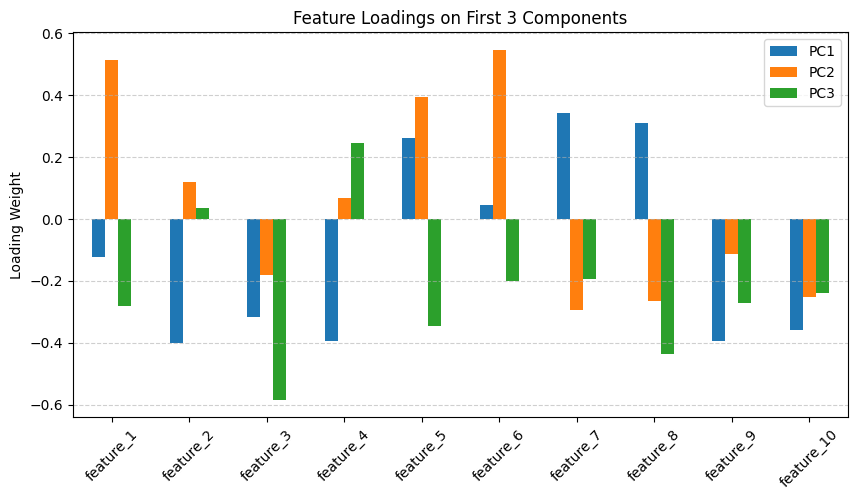

In [32]:
loadings_df = pd.DataFrame(V[:, :k],
                           index=df.columns,
                           columns=[f"PC{i+1}" for i in range(k)])
print(loadings_df.head())

# visualize the first three components
loadings_df.plot(kind='bar', figsize=(10,5))
plt.title("Feature Loadings on First 3 Components")
plt.ylabel("Loading Weight")
plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.show()

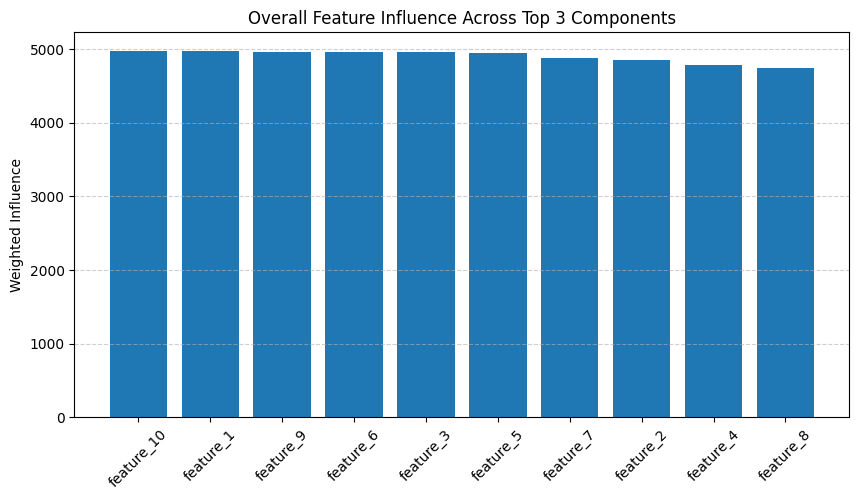

In [33]:
influence = np.sum((sigma[:k]**2) * (V[:, :k]**2), axis=1)
influence_series = pd.Series(influence, index=df.columns).sort_values(ascending=False)

# plot global influence
plt.figure(figsize=(10,5))
plt.bar(influence_series.index, influence_series.values)
plt.title("Overall Feature Influence Across Top 3 Components")
plt.ylabel("Weighted Influence")
plt.xticks(rotation=45)
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.show()

In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

# realistic variable names
columns = [
    'pos_x','pos_y','pos_z',
    'vel_x','vel_y','vel_z',
    'acc_x','acc_y','acc_z',
    'ang_pos_roll','ang_pos_pitch','ang_pos_yaw',
    'ang_vel_roll','ang_vel_pitch','ang_vel_yaw'
]

# create correlated motion patterns
time_steps = 5000
base_motion = np.random.randn(time_steps, 3)  # 3 latent motion sources

# project base motions into 15 sensors (columns)
A = base_motion @ np.random.randn(3, len(columns)) + 0.1*np.random.randn(time_steps, len(columns))
df = pd.DataFrame(A, columns=columns)

# standardize
A_scaled = StandardScaler().fit_transform(df)

In [35]:
U, sigma, Vt = np.linalg.svd(A_scaled, full_matrices=False)
V = Vt.T

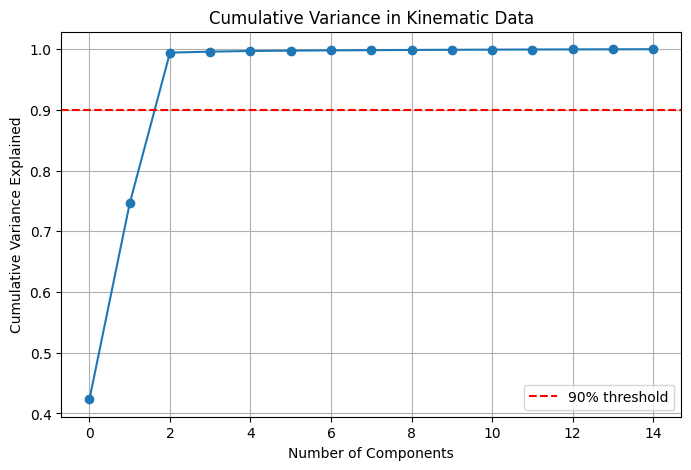

Keep the first 3 components to explain 90% of total motion variance.


In [36]:
var_explained = (sigma**2) / np.sum(sigma**2)
cum_var = np.cumsum(var_explained)

plt.figure(figsize=(8,5))
plt.plot(cum_var, marker='o')
plt.axhline(0.9, color='r', linestyle='--', label='90% threshold')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance Explained")
plt.title("Cumulative Variance in Kinematic Data")
plt.legend()
plt.grid(True)
plt.show()

k = np.argmax(cum_var >= 0.9) + 1
print(f"Keep the first {k} components to explain 90% of total motion variance.")

In [37]:
for i in range(k):
    loadings = pd.Series(V[:, i], index=df.columns)
    top_features = loadings.abs().sort_values(ascending=False).head(5)
    print(f"\nTop features influencing Component {i+1}:")
    print(top_features)


Top features influencing Component 1:
pos_z           0.380227
ang_vel_roll    0.350864
pos_y           0.338534
vel_x           0.322661
pos_x           0.313128
dtype: float64

Top features influencing Component 2:
acc_x            0.452506
ang_vel_yaw      0.398605
ang_vel_pitch    0.329223
acc_z            0.324066
ang_pos_yaw      0.322027
dtype: float64

Top features influencing Component 3:
ang_pos_pitch    0.477866
ang_pos_roll     0.409107
acc_y            0.315240
pos_x            0.313699
vel_z            0.296696
dtype: float64


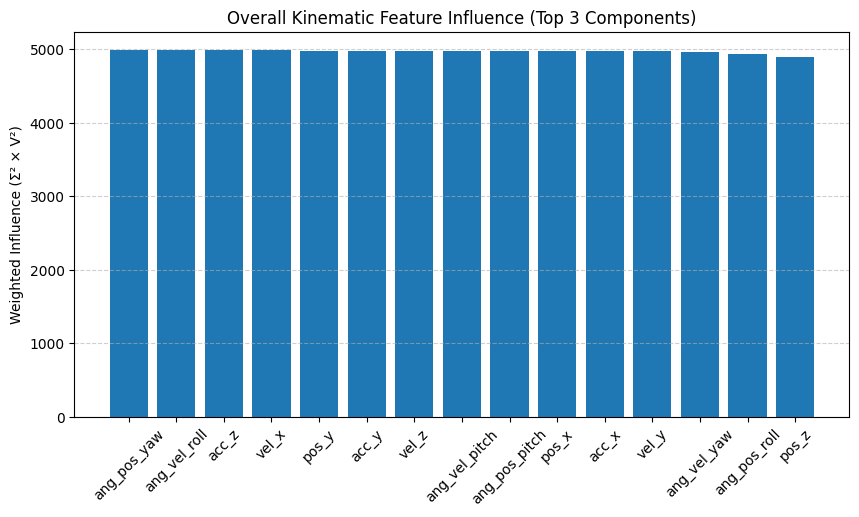


Top globally influential features:
ang_pos_yaw      4987.526567
ang_vel_roll     4986.795660
acc_z            4986.501602
vel_x            4985.524345
pos_y            4984.557399
acc_y            4983.457351
vel_z            4982.653125
ang_vel_pitch    4980.098969
dtype: float64


In [38]:
influence = np.sum((sigma[:k]**2) * (V[:, :k]**2), axis=1)
influence_series = pd.Series(influence, index=df.columns).sort_values(ascending=False)

plt.figure(figsize=(10,5))
plt.bar(influence_series.index, influence_series.values)
plt.xticks(rotation=45)
plt.ylabel("Weighted Influence (Σ² × V²)")
plt.title(f"Overall Kinematic Feature Influence (Top {k} Components)")
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.show()

print("\nTop globally influential features:")
print(influence_series.head(8))